In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ai_job_replacement_2020_2026_v2.csv")

Veri Seti Hikayesi

Yapay zeka çağında işin geleceği 2020-2026

Bu veri seti, yapay zekâ ve otomasyon teknolojilerinin 2020 ile 2026 yılları arasında küresel iş piyasasını nasıl etkilediğine dair kapsamlı bir genel bakış sunmaktadır. Otomasyon riski, yapay zeka benimseme düzeyleri, maaş değişiklikleri, işgücü talebi ve beceri açıkları gibi temel göstergelere odaklanan, birden fazla sektör ve iş rolünden veriler içermektedir.

Özetle yapay zekanın işler üzerindeki etkisini, özellikle otomasyon riski, maaş değişiklikleri ve sektörler genelindeki beceri açıkları gibi durumları inceleyeğiz

Bir mesleğin otomasyon riski düşük mü, orta mı, yüksek mi?

In [3]:
df.head()    #meslek, sektör, ülke, otomasyon riski yüzdesi, yapay zeka ile yer değiştirme skoru

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  object 
 2   industry                     15000 non-null  object 
 3   country                      15000 non-null  object 
 4   year                         15000 non-null  int64  
 5   automation_risk_percent      15000 non-null  float64
 6   ai_replacement_score         15000 non-null  float64
 7   skill_gap_index              15000 non-null  float64
 8   salary_before_usd            15000 non-null  float64
 9   salary_after_usd             15000 non-null  float64
 10  salary_change_percent        15000 non-null  float64
 11  skill_demand_growth_percent  15000 non-null  float64
 12  remote_feasibility_score     15000 non-null  float64
 13  ai_adoption_leve

In [5]:
df.isnull().sum()

job_id                         0
job_role                       0
industry                       0
country                        0
year                           0
automation_risk_percent        0
ai_replacement_score           0
skill_gap_index                0
salary_before_usd              0
salary_after_usd               0
salary_change_percent          0
skill_demand_growth_percent    0
remote_feasibility_score       0
ai_adoption_level              0
education_requirement_level    0
automation_risk_category       0
skill_transition_pressure      0
wage_volatility_index          0
reskilling_urgency_score       0
ai_disruption_intensity        0
dtype: int64

In [6]:
df.shape

(15000, 20)

In [7]:
df.duplicated().sum()

0

In [8]:
df.columns

Index(['job_id', 'job_role', 'industry', 'country', 'year',
       'automation_risk_percent', 'ai_replacement_score', 'skill_gap_index',
       'salary_before_usd', 'salary_after_usd', 'salary_change_percent',
       'skill_demand_growth_percent', 'remote_feasibility_score',
       'ai_adoption_level', 'education_requirement_level',
       'automation_risk_category', 'skill_transition_pressure',
       'wage_volatility_index', 'reskilling_urgency_score',
       'ai_disruption_intensity'],
      dtype='object')

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
job_id,15000.0,7499.500000,4330.271354,0.000000,3749.750000,7499.500000,11249.250000,14999.000000
year,15000.0,2022.997200,1.999365,2020.000000,2021.000000,2023.000000,2025.000000,2026.000000
automation_risk_percent,15000.0,46.176347,21.663635,5.000000,28.790000,46.235000,63.602500,94.980000
ai_replacement_score,15000.0,46.155907,22.351347,4.010000,28.357500,45.675000,62.712500,113.070000
skill_gap_index,15000.0,50.003708,28.811040,0.000000,25.170000,49.930000,75.025000,99.980000
salary_before_usd,15000.0,89771.375196,34522.125434,30003.690000,60127.225000,89533.050000,119823.840000,149984.060000
salary_after_usd,15000.0,89870.633937,35897.592992,19022.670000,59223.457500,88787.330000,118432.967500,191961.210000
salary_change_percent,15000.0,0.114268,10.029197,-38.370000,-6.640000,0.150000,6.690000,36.920000
skill_demand_growth_percent,15000.0,5.020461,9.956155,-31.880000,-1.662500,4.960000,11.730000,49.790000
remote_feasibility_score,15000.0,54.898078,25.863593,10.010000,32.517500,54.775000,77.405000,99.990000


otomasyon risk(bir işin yapay zekaya devredilmesi ile ortaya çıkabilecek olumsuzluklar ve belirsizliklerdir. işsizlik gibi durumlar doğurabilir) yüzdesi ortalama %46 bu durum incelenen mesleklerin büyük bir kısmının otomasyon açısından orta seviyede risk taşıdığını gösterir.

yapay zeka ile yer değiştirme skoru(Bu değişken, yapay zekanın o mesleği ne kadar kolay yapabileceğini gösteren bir skordur.) değişkeninin ortalaması da yaklaşık 46  civarındadır. bu değer otomasyon risk yüzdesi ile paralel bir dağılım göstermektedir ve yapay zekanın birçok meslekte belirli bir etkiye sahip olduğu bellidir.

beceri açığı indeksinin(çalışanların mevcut becerileri ile gelecekte ihtiyaç duyaacağı beceriler arasındaki farkı ölçer. bu değer yüksekse çalışanların yeni beceriler öğrenmesi gerekir.) ortalaması yaklaşık 50 civarında. Yani çalışanların mevcut becerileri ile gelecekte ihtiyaç duyulacak becerileri arasında orta seviyede fark olduğu gözlemlenir.

otomasyon öncesi maaş ile otomasyon sonrası maaş çok yakın. Bu durum genel olarak otomasyonun maaşlar üzerinde çok büyük bir değişime neden olmadığı ama bazı mesleklerde farklı etkiler yaratabileceği gözlemlenir.

maaş değişim yüzdesi min = -38, max = +36 yani bazı mesleklerde yüzde 38 artarken bazı mesleklerde maaş yüzde 36 artmış. yani otomasyon bazı meslekleri olumlu bazı meslekleri olumsuz etkilemiş.

uzaktan çalışma uygunluk skoru yaklaşık 54. yani veri setindeki mesleklerin önemli bir kısmı uzaktan çalışmaya uygundur.

Yapay zeka benimsenme seviyesi(bir sektörde yapay zekanın ne kadar kullanıldığını gösterir.) ortalama 49 civarında. Yani sektörlerde yapay zekanın orta seviyede benimsendiği gözlemlenmekte. bazı sektörlerde çok yoğun kullanılırken bazılarında çok az seviyede kullanılmış.

eğitim gereksinim seviyesi min=1, max=5 . mesleğin ne kadar eğitim gerektirdiğini gösterir. 1 düşük eğitim, 3 orta eğitim, 5 yüksek eğitim

Yeniden beceri kazanma aciliyeti ortalama 35 civarında. bu durum bazı mesleklerde çalışanların yeni beceriler öğrenme ihtiyacının bulunduğunu gösterir. yapay zekanın hızlı geliştiği sektörlerde bu değer daha yüksek olur.

yapay zekanın sektörü bozma gücü(yani yapay zekanın o sektörü ne kadar değiştirdiği) teknoloji sektörünü yüksek etkilerken sanat sektörünü düşük etkilemiş gibi durumları örnek verebiliriz.

Özetle veri setindeki sayısal değişkenlerin dağılımı incelendiğinde yapay zekanın iş gücü üzerinde etkisinin orta seviyede fakat artan bir etkiye sahip olduğu söylenebilir. Yani yapay zekanın iş gücünü tamamen ortadan kaldırmadığı ancak mesleklerin dönüşmesine neden olduğunu gözlemleyebiliriz

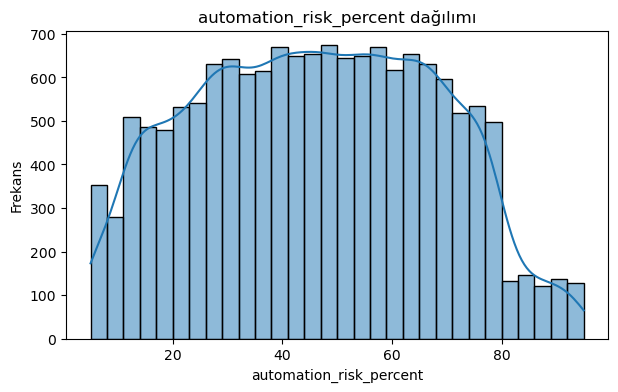

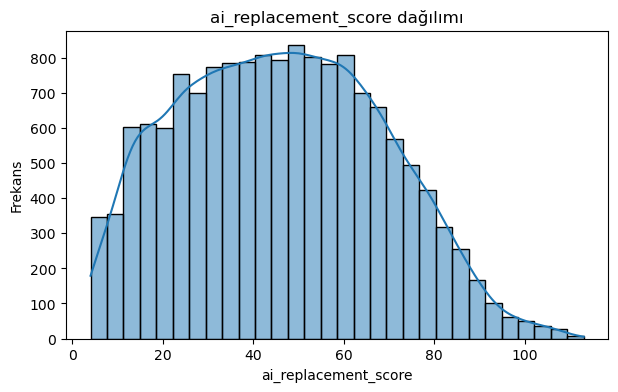

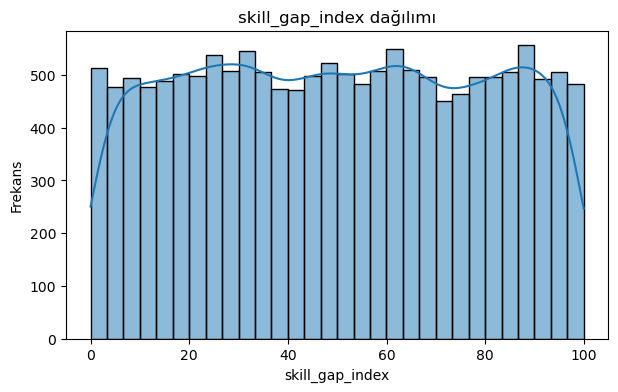

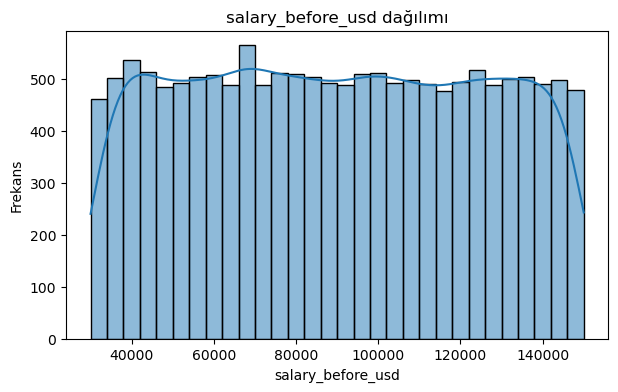

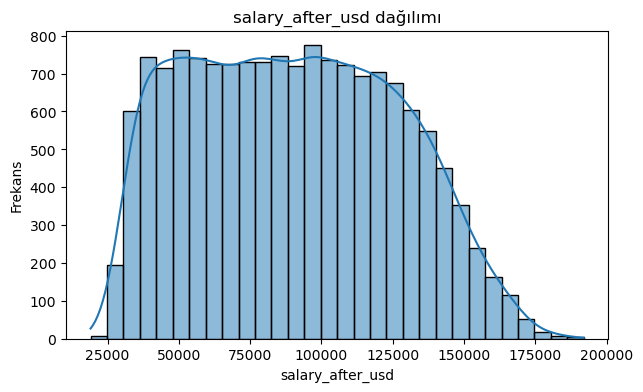

In [10]:
sayisal_deg = [
    "automation_risk_percent",
    "ai_replacement_score",
    "skill_gap_index",
    "salary_before_usd",
    "salary_after_usd"
]

for col in sayisal_deg:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"{col} dağılımı")
    plt.xlabel(col)
    plt.ylabel("Frekans")
    plt.show()                                                 #önemli sayısal değişkenlerin dağılımı

otomasyon risk yüzdesinin veri setindeki dağılımı incelendiğinde risk değerinin yaklaşık %10 ile %95 aralığında olduğu gözlemlenir. ama en yoğun değerler 30-70 aralığında . bu durum veri setindeki mesleklerin büyük kısmı orta seviyede otomasyon riski taşıdığı gözlemlenir.

yapay zeka ile yer değiştirme skoru dağılımında veri setindeki mesleklerin önemli bir kısmı yapay zekanın belirli bir düzeyde etkili olabileceğini göstermektedir.

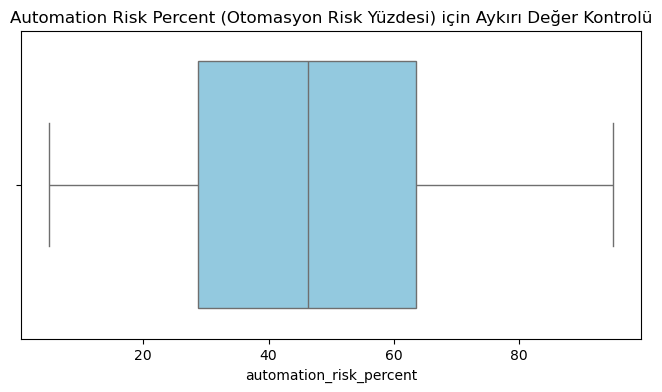

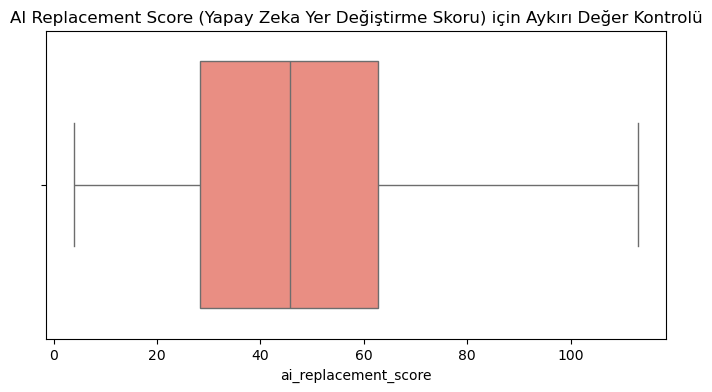

In [11]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["automation_risk_percent"], color="skyblue")
plt.title("Automation Risk Percent (Otomasyon Risk Yüzdesi) için Aykırı Değer Kontrolü")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["ai_replacement_score"], color="salmon")
plt.title("AI Replacement Score (Yapay Zeka Yer Değiştirme Skoru) için Aykırı Değer Kontrolü")
plt.show()

kutu grafikleri incelediğimde aykırı değer gözlemlemedim bu durum da veri setinin değişken açısından dengeli, uç değerler içermediğini ve temiz bir dağılımda olduğunu gösterir. 

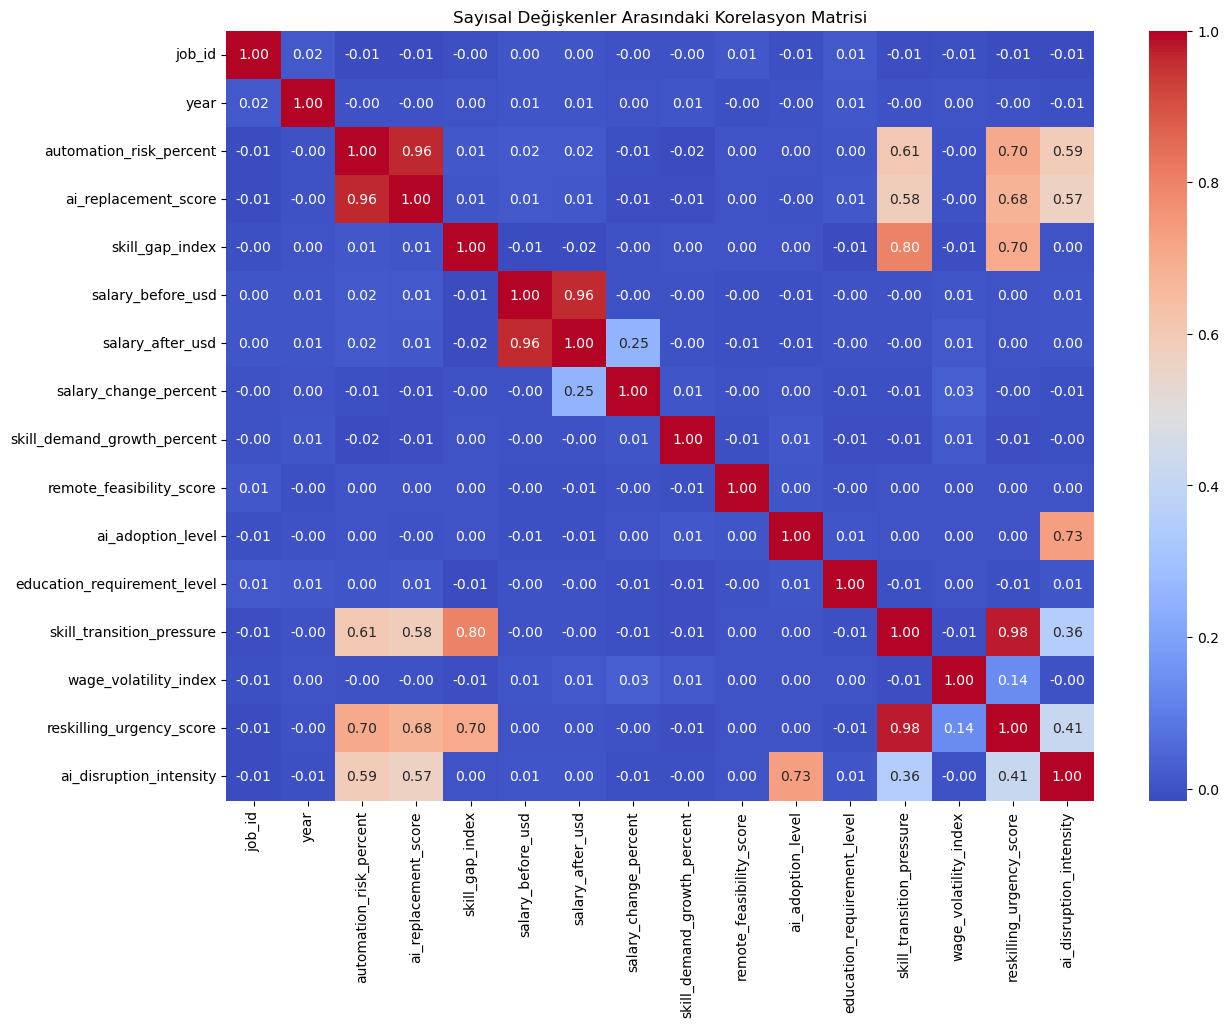

In [12]:
plt.figure(figsize=(14,10))
corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Sayısal Değişkenler Arasındaki Korelasyon Matrisi")
plt.show()

sayısal değişkenler arasındaki ilişkiyi korelasyon matrisi ile incelediğimizde kırmızı renkler güçlü pozitif ilişkiyi gösterirken mavi renk ise zayıf ilişkiyi gösterir. 

otomasyon riski ile yapay zeka ile yer değiştirme skorunun korelasyon değeri 1 e yakın pozitif bir ilişki içinde yani yapay zekanın bir işi yapabilme skoru arttıkça o mesleğin otomasyon riski de artmaktadır.

ortomasyon öncesi maaş ile otomasyon sonrası maaşın korelasyon değeri de 0.96 güçlü bir ilişki. yani otomasyon öncesi maaşı yüksek olan mesleklerde otomasyon sonrası maaş da genellikle yüksek kalmaktadır denebilir.

beceri açığı ve beceri dönüşüm açığı korelasyon değeri 0.80 güçlü bir ilişki. yani beceri açığı arttıkça çalışanların yeni becceriler öğrenme baskısı da artmaktadır. bu durum iş gücü dönüşümünü gösteren önemli bir bulgudur.

yeniden eğitim ihtiyacı ile otomasyon riski arasında korelasyon değeri yaklaşık 0.70 yani otomasyon riski yüksek olan mesleklerde çalışanların yeni beceriler öğrenme ihtiyacı da fazladır. bu durum yapay zekanın iş gücünde yeniden eğitim gerekliliğini arttırdığıı gösterir.

bazır değişkenlerin korelasyonunun 0 a yakın olduğu gözlemlenmekte yıl, uzaktan çalışma uygunluğu gibi. bu durum bu değişkenlerin diğer değişkenlerle ilişkisinin güçlü olmadığını gösterir.

C:\Users\onnal\AppData\Local\Temp\ipykernel_13392\3710168553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_risk.index, y=sector_risk.values, palette="viridis")


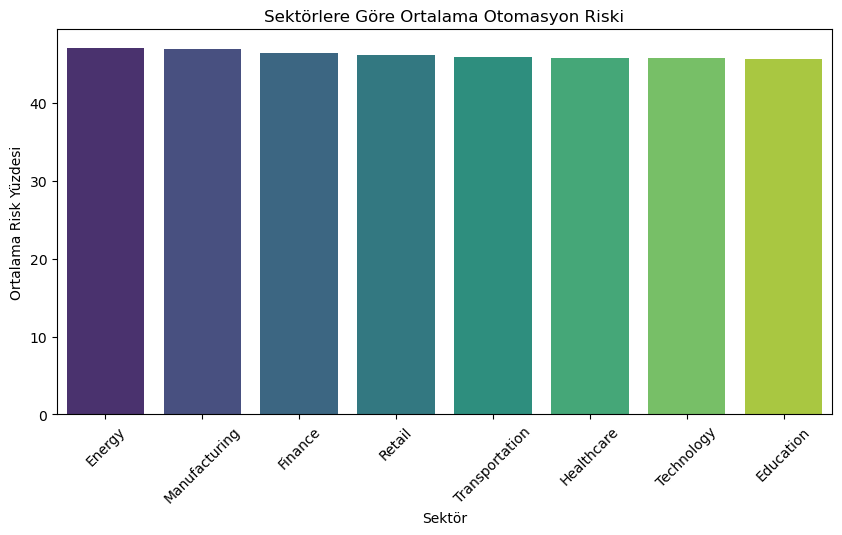

In [13]:
plt.figure(figsize=(10,5))
sector_risk = df.groupby("industry")["automation_risk_percent"].mean().sort_values(ascending=False)

sns.barplot(x=sector_risk.index, y=sector_risk.values, palette="viridis")
plt.title("Sektörlere Göre Ortalama Otomasyon Riski")
plt.xlabel("Sektör")
plt.ylabel("Ortalama Risk Yüzdesi")
plt.xticks(rotation=45)
plt.show()

grafik incelendiğinde sektörler arasında otomasyon riskinin genel olarak benzer seviyelerde dağıldığı görülmekte(%45-47). enerji ve üretim sektörlerindeki otomasyon riskinin diğer sektörlere göre biraz daha yüksek olduğu görülmekte. teknoloji ve eğitim gibi sektörlerde otomasyon riski biraz daha düşük seviyelerde. 

C:\Users\onnal\AppData\Local\Temp\ipykernel_13392\3038737279.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_risk.index, y=country_risk.values, palette="magma")


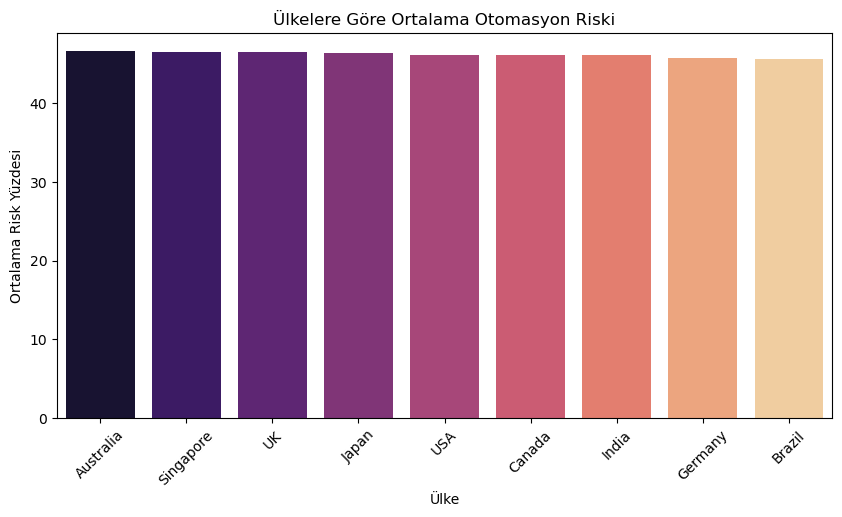

In [14]:
plt.figure(figsize=(10,5))
country_risk = df.groupby("country")["automation_risk_percent"].mean().sort_values(ascending=False)

sns.barplot(x=country_risk.index, y=country_risk.values, palette="magma")
plt.title("Ülkelere Göre Ortalama Otomasyon Riski")
plt.xlabel("Ülke")
plt.ylabel("Ortalama Risk Yüzdesi")
plt.xticks(rotation=45)
plt.show()

grafiğe göre ülkeler arasında otomasyon riskinin çok büyük farklılıklar göstermediği gözlemlenmekte
yapay zeka ve otomasyon teknolojilerinin iş gücü üzerindeki etkisi yalnızca belirli ülkelerle sınırlı değildir. küresel ölçekte benzer seviyelerde hissedilir.

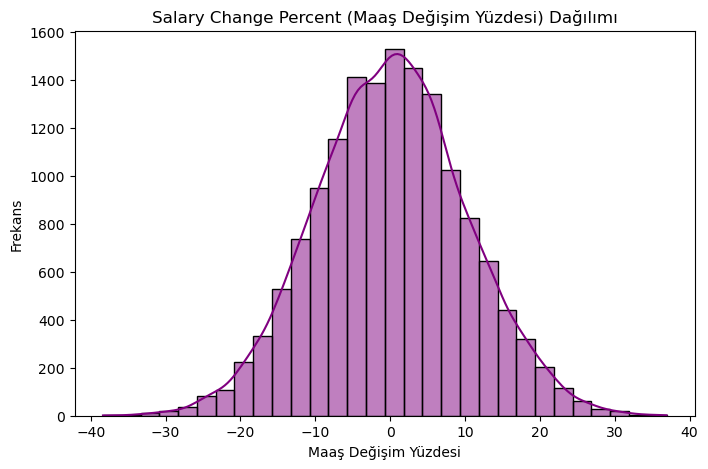

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["salary_change_percent"], kde=True, bins=30, color="purple")
plt.title("Salary Change Percent (Maaş Değişim Yüzdesi) Dağılımı")
plt.xlabel("Maaş Değişim Yüzdesi")
plt.ylabel("Frekans")
plt.show()

otomasyon ve yapay zeka etkisi sonrası mesleklerin maaşında -38, +36 aralığında değişim olduğu gözlemlendi ama dağılım büyük ölçüde 0 etrafında yoğunlaşyor. yani veri setindeki mesleklerin büyük bir kısmında otomasyonun maaşlar üzerinde çok büyük bir etki yaratmadığı gözlemlenir.

In [16]:
df = df.drop("job_id", axis=1)

bu veri setinde en uygun hedef değişken otomasyon risk kategorisi. Çünkü bu sütun kategori içeriyor. yani sınıflandırma yapabiliriz.

In [17]:
df["automation_risk_category"].value_counts()   #Hedef değişkenin sınıf dağılımı(düşük,orta,yüksek)

automation_risk_category
Medium    6464
High      4496
Low       4040
Name: count, dtype: int64

C:\Users\onnal\AppData\Local\Temp\ipykernel_13392\2564459997.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df["automation_risk_category"], palette = "Set2")


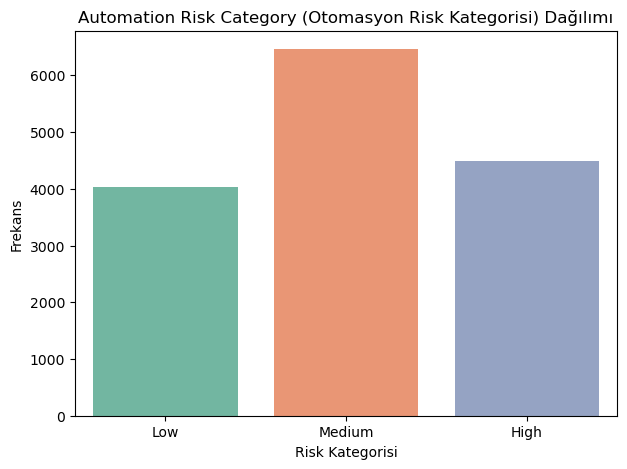

In [18]:
plt.figure(figsize=(7,5))
sns.countplot(x = df["automation_risk_category"], palette = "Set2")
plt.title("Automation Risk Category (Otomasyon Risk Kategorisi) Dağılımı")
plt.xlabel("Risk Kategorisi")
plt.ylabel("Frekans")
plt.show()                                 #otomasyon risk kategorisi değişkeninin sınıf dağılımı

orta risk kategorisi veri setinde en fazla gözleme sahip. düşük ve yüksek risk kategorileri birbirine daha yakın sayıda gözlem içermektedir. Genel olarak sınıflar eşit olmasa da çok dengesiz bir dağılım bulunmamaktadır.

bağımlı değişkenim y (target) = otomasyon risk yüzdesi

bağımsız değişken X = hedef sütun dışındaki tüm sütunlar

In [19]:
X = df.drop("automation_risk_category", axis=1)
y = df["automation_risk_category"]

In [20]:
X = pd.get_dummies(X, drop_first = True)   #kategorik veriler sayısal hale getirildi.(makine öğrenmesi algoritmaları metinsel verilerle çalışmaz.)

In [21]:
#veriyi bozma
df_bozuk = df.copy()

df_bozuk.loc[0:10, "salary_before_usd"] = np.nan
df_bozuk.loc[20:30, "ai_replacement_score"] = np.nan

print("Kirli veri setindeki eksik değer sayıları:")
print(df_bozuk.isnull().sum())

Kirli veri setindeki eksik değer sayıları:
job_role                        0
industry                        0
country                         0
year                            0
automation_risk_percent         0
ai_replacement_score           11
skill_gap_index                 0
salary_before_usd              11
salary_after_usd                0
salary_change_percent           0
skill_demand_growth_percent     0
remote_feasibility_score        0
ai_adoption_level               0
education_requirement_level     0
automation_risk_category        0
skill_transition_pressure       0
wage_volatility_index           0
reskilling_urgency_score        0
ai_disruption_intensity         0
dtype: int64


In [22]:
#veriyi temizleme
df_bozuk["salary_before_usd"] = df_bozuk["salary_before_usd"].fillna(df_bozuk["salary_before_usd"].mean())
df_bozuk["ai_replacement_score"] = df_bozuk["ai_replacement_score"].fillna(df_bozuk["ai_replacement_score"].mean())

print("Temizleme sonrası eksik değer sayıları:")
print(df_bozuk.isnull().sum())

Temizleme sonrası eksik değer sayıları:
job_role                       0
industry                       0
country                        0
year                           0
automation_risk_percent        0
ai_replacement_score           0
skill_gap_index                0
salary_before_usd              0
salary_after_usd               0
salary_change_percent          0
skill_demand_growth_percent    0
remote_feasibility_score       0
ai_adoption_level              0
education_requirement_level    0
automation_risk_category       0
skill_transition_pressure      0
wage_volatility_index          0
reskilling_urgency_score       0
ai_disruption_intensity        0
dtype: int64


In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)                                                        # %80 eğitim, %20 test verisi

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)            #Standardizasyon(veri ölçekleme) = ortalamayı 0, standart sapmayı 1 olacak şekilde dönüştürür.

In [27]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

X_train_norm = minmax_scaler.fit_transform(X_train)
X_test_norm = minmax_scaler.transform(X_test)

print("Normalizasyon tamamlandı.")
print("X_train_norm şekli:", X_train_norm.shape)
print("X_test_norm şekli:", X_test_norm.shape)             #normalizasyon(verinin min, max değerlerini gözlemleyerek veriyi 0-1 aralığında ölçekledik)

Normalizasyon tamamlandı.
X_train_norm şekli: (12000, 39)
X_test_norm şekli: (3000, 39)


%80 eğitim, %20 test verisi. 

modelin değişkenler arasındaki ölçek farklarından etkilenmesi önlenmiştir.

In [28]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [29]:
model = SVC(kernel = "rbf")
model.fit(X_train_std, y_train)               #model standardize edilmiş veri ile eğitildi

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Destek vektör makinesi kuruldu. SVM algoritmasının amacı veri noktalarını en iyi şekilde ayıran hiperdüzlemi bulmaktır. Doğrusal olmayan veri ilişkisini öğrenebilmek için kullanılır.

SVM sınıflandırma problemlerinde güçlü bir algoritmadır

Özellikle orta boyutlu veri setlerinde iyi performans gösterir

Verileri ayıran en iyi karar sınırını  bulur

kernel fonksiyonları sayesinde doğrusal olmayan ilişkileri öğrenebilir

In [30]:
y_pred = model.predict(X_test_std)       #tahmin

In [31]:
model_norm = SVC(kernel="rbf")
model_norm.fit(X_train_norm, y_train)

y_pred_norm = model_norm.predict(X_test_norm)     #model normalize edilmiş veri ile eğitildi

In [32]:
print("Standartlaştırılmış veri ile doğruluk:", accuracy_score(y_test, y_pred))
print("Normalize edilmiş veri ile doğruluk:", accuracy_score(y_test, y_pred_norm))

Standartlaştırılmış veri ile doğruluk: 0.9533333333333334
Normalize edilmiş veri ile doğruluk: 0.95


bu veri setinde her iki yöntem de benzer yakınlıkta fakat StandardScaler daha iyi çalıştı doğruluk oranı daha yüksek.

In [33]:
accuracy_score(y_test, y_pred)             #model başarısı

0.9533333333333334

In [34]:
from sklearn.metrics import confusion_matrix

Confusion Matrix (karmaşıklık matrisi), sınıflandırma modellerinin performansını detaylı olarak analiz etmek için kullanılan bir tablodur. modelin doğru tahminleri, yanlış tahminleri, hangi sınıfların birbiriyle karıştırıldığı görülür

In [35]:
confusion_matrix(y_test, y_pred)          

array([[ 861,    0,   38],
       [   0,  772,   36],
       [  36,   30, 1227]], dtype=int64)

0 = high, 1 = low, 2 = medium
high sınıfı 861 doğru 38 yanlış
low sınıfı 772 doğru 36 yanlış
medium 1227 doğru ancak bazı medium sınıfları high ve low ile karıştırılmış. normal bir durum.
özetle model yüksek doğrulukta sınıflandırma yapıyor diyebiliriz.

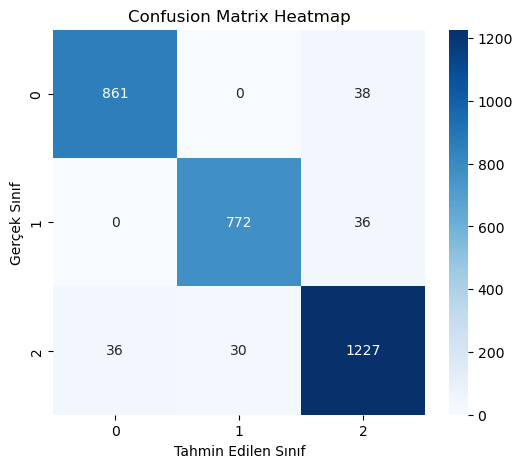

In [36]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.show()

In [37]:
ornek_veri = pd.DataFrame({
    "job_role": ["Data Analyst"],
    "industry": ["Technology"],
    "country": ["Canada"],
    "year": [2025],
    "automation_risk_percent": [60],
    "ai_replacement_score": [65],
    "skill_gap_index": [50],
    "salary_before_usd": [70000],
    "salary_after_usd": [72000],
    "salary_change_percent": [3],
    "skill_demand_growth_percent": [10],
    "remote_feasibility_score": [70],
    "ai_adoption_level": [60],
    "education_requirement_level": [3],
    "skill_transition_pressure": [55],
    "wage_volatility_index": [8],
    "reskilling_urgency_score": [40],
    "ai_disruption_intensity": [30]
})

ornek_veri = pd.get_dummies(ornek_veri, drop_first=True)
ornek_veri = ornek_veri.reindex(columns=X_train.columns, fill_value=0)

ornek_veri_std = scaler.transform(ornek_veri)

tahmin = model.predict(ornek_veri_std)

print("Tahmin edilen otomasyon risk kategorisi:", tahmin[0])

Tahmin edilen otomasyon risk kategorisi: Medium
